In [1]:
import json
import re

import matplotlib.pyplot as plt

## Evaluation

In [2]:
# with open("data/datasets/distractors_sample_prompt_v3/distractors_preliminary_comp_gtp4omini.json", "r+") as f:
with open("data/datasets/baseline/distractors_preliminary_llama.json", "r+") as f:
    data = json.load(f)
    print(f"Loaded dataset of {len(data)} MWPs")

Loaded dataset of 50 MWPs


### Dataset

(array([ 0., 12.,  9., 11., 18.]),
 array([1., 2., 3., 4., 5., 6.]),
 <BarContainer object of 5 artists>)

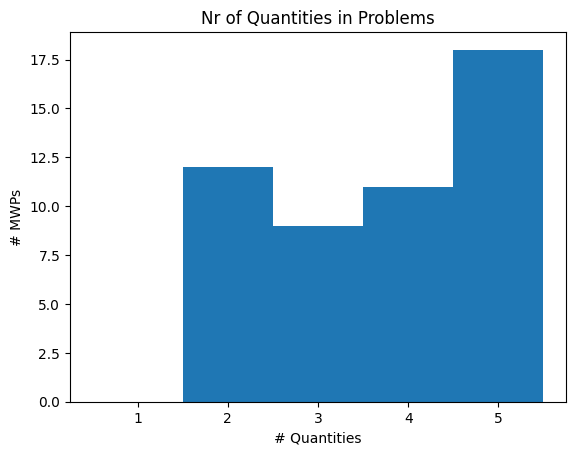

In [3]:
# nr of quantities per MWP
quants = []
for mwp_id in data:
    mwp_data = data[mwp_id]
    for num_inst in mwp_data["instantiations"]:
        num_inst_data = mwp_data["instantiations"][num_inst]
        num_quant = len(num_inst_data["instantiation"])
        quants.append(num_quant)
        break

plt.title("Nr of Quantities in Problems")
plt.xlabel("# Quantities")
plt.ylabel("# MWPs")
plt.hist(quants, align="left", bins=list(range(1, max(quants)+1)))

(array([12.,  9., 29.]),
 array([1., 2., 3., 4.]),
 <BarContainer object of 3 artists>)

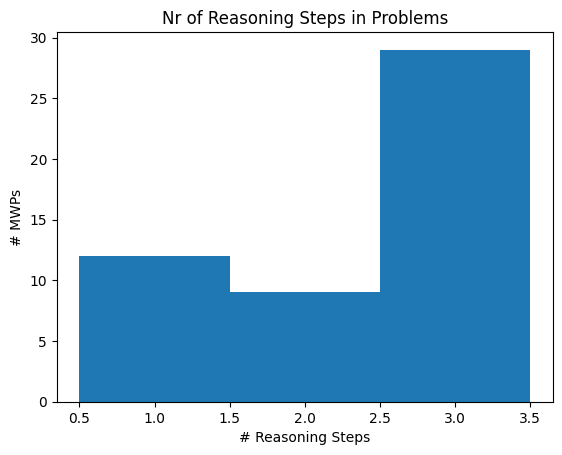

In [4]:
# nr of reasoning steps per mwp
nr_steps = []
for mwp_id in data:
    mwp_data = data[mwp_id]

    steps = len(mwp_data["metadata"]["orig_rules_by_conclusion"])
    nr_steps.append(steps)

plt.title("Nr of Reasoning Steps in Problems")
plt.xlabel("# Reasoning Steps")
plt.ylabel("# MWPs")
plt.hist(nr_steps, align="left", bins=list(range(1, max(nr_steps)+1)))

### Solvability
1. How many numerical instantiations are solved correctly overall?
2. How many MWPs are solvable (correct solution for the majority of numerical instantiations)? 
3. For how many numerical instantiations does the given answer match the inconsistent answer (i.e. the LLM shares the same misconception)?

In [5]:
solved_threshold = 0.5 # fraction of numerical instantiations that should be solved correctly for a problem to be considered solvable

In [6]:
solved_by_mwp_by_num_inst = {}
solvable_by_mwp = {}
matches_incorrect_by_mwp_by_num_inst = {}
for mwp_id in data:
    mwp_data = data[mwp_id]
    solved_by_mwp_by_num_inst[mwp_id] = {}
    matches_incorrect_by_mwp_by_num_inst[mwp_id] = {}

    solved_cnt = 0
    for num_inst in mwp_data["instantiations"]:
        num_inst_data = mwp_data["instantiations"][num_inst]
        correct_answer = num_inst_data["correct_answer"]["answer"]
        llm_answer = num_inst_data["llm_answer"]["extracter_answer"]
        
        solved = (correct_answer == llm_answer)
        solved_by_mwp_by_num_inst[mwp_id][num_inst] = solved
        
        incon_match = any([
            d["answer"] == llm_answer
            for d in num_inst_data["misconception_answers"]
            if d["plausible"]
        ])
        matches_incorrect_by_mwp_by_num_inst[mwp_id][num_inst] = incon_match

        if solved:
            solved_cnt += 1
    
    mwp_solveable = solved_cnt / len(mwp_data["instantiations"]) >= solved_threshold
    solvable_by_mwp[mwp_id] = mwp_solveable

print(f"Correctly solved: {sum(list(i.values()).count(True) for i in solved_by_mwp_by_num_inst.values())} / {sum(len(i.values()) for i in solved_by_mwp_by_num_inst.values())}")
print(f"Solvable: {list(solvable_by_mwp.values()).count(True)} / {len(solvable_by_mwp)}")
print(f"Given answer matches any inconsistent one: {sum(list(i.values()).count(True) for i in matches_incorrect_by_mwp_by_num_inst.values())} / {sum(len(i.values()) for i in matches_incorrect_by_mwp_by_num_inst.values())}")

Correctly solved: 111 / 150
Solvable: 37 / 50
Given answer matches any inconsistent one: 8 / 150


In [7]:
# are problems with hypothetical formulations like "if we were to" more difficult to solve
solved_hypo = 0
total_hypo = 0
solved_normal = 0
total_normal = 0
for mwp_id in data:
    mwp_data = data[mwp_id]
    for num_inst in mwp_data["instantiations"]:
        num_inst_data = mwp_data["instantiations"][num_inst]
        is_hypo = "If we" in num_inst_data["problem"]
        solved = solved_by_mwp_by_num_inst[mwp_id][num_inst]
        if is_hypo:
            solved_hypo += solved
            total_hypo += 1
        else:
            solved_normal += solved
            total_normal += 1
print(f"Solved problems with hypothetical formulations: {solved_hypo}/{total_hypo} = {round(100*solved_hypo/total_hypo)}%")
print(f"Solved problems without hypothetical formulations: {solved_normal}/{total_normal} = {round(100*solved_normal/total_normal)}%")

Solved problems with hypothetical formulations: 32/69 = 46%
Solved problems without hypothetical formulations: 79/81 = 98%


Text(0.5, 0, '# Reasoning Steps')

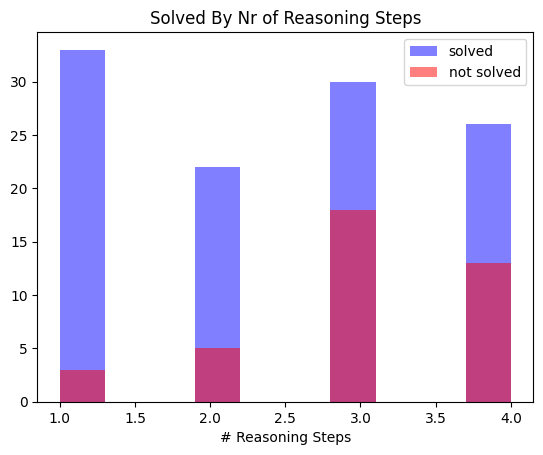

In [8]:
# solved by nr of reasoning steps
solved = []
nr_steps = []
for mwp_id in data:
    mwp_data = data[mwp_id]
    for num_inst in mwp_data["instantiations"]:
        num_inst_data = mwp_data["instantiations"][num_inst]

        solved.append(solved_by_mwp_by_num_inst[mwp_id][num_inst])
        nr_steps.append(len(mwp_data["metadata"]["orig_rules_by_conclusion"]))

plt.title("Solved By Nr of Reasoning Steps")
plt.hist([nr for nr,s in zip(nr_steps, solved) if s], color="blue", alpha=0.5, label="solved")
plt.hist([nr for nr,s in zip(nr_steps, solved) if not s], color="red", alpha=0.5, label="not solved")
plt.legend()
plt.xlabel("# Reasoning Steps")


In [9]:
# are problems with some type of inference rule?
solved_by_rule = {}
total_by_rule = {}
for mwp_id in data:
    mwp_data = data[mwp_id]
    for num_inst in mwp_data["instantiations"]:
        num_inst_data = mwp_data["instantiations"][num_inst]
        
        solved = solved_by_mwp_by_num_inst[mwp_id][num_inst]
        for rule in set(mwp_data["metadata"]["orig_rules_by_conclusion"].values()):
            solved_by_rule[rule] = solved_by_rule.get(rule, 0) + solved
            total_by_rule[rule] = total_by_rule.get(rule, 0) + 1

for rule in total_by_rule:
    print(f"Solved problems including rule {rule}: {solved_by_rule.get(rule, 0)}/{total_by_rule.get(rule, 0)} = {round(100*solved_by_rule.get(rule, 0)/total_by_rule.get(rule, 0))}%")

Solved problems including rule ContPartWhole: 21/42 = 50%
Solved problems including rule ContCompCompeqCont: 39/69 = 57%
Solved problems including rule ContTransferCont: 87/111 = 78%
Solved problems including rule ContContComp: 23/27 = 85%
Solved problems including rule ContCompCont: 54/78 = 69%


### Inconsistency Bias
1. How often do the suggested distractors match the ones we’d get if any form of inconsistency bias is applied? (considering all correctly solved numerical instantiations of all mwps)
2. How often do the suggested distractors match the correct answer?
3. How often do the suggested distractors match the llms suggested answer?
4. For how many solvable MWPs do the suggested distractors match the ones we’d get if inconsistency bias is applied for the majority of correctly solved numerical instantiations? (per mwp, exclude randomness) 

E.g. if for mwp0, the LLM answers correctly for ninst0, ninst2 and ninst3, then mwp0 is considered solvable. If for two out of { ninst0, ninst2, ninst3 }, the distractors the LLM suggests match any distractor of our inconsistency–distractor-set, we consider them count that MWP as having non-random inconsistency-misconception-based distractors.

In [10]:
incon_match_by_mwp_by_num_inst = {}
incon_match_by_mwp = {}
incon_eq_correct_by_mwp_by_num_inst = {} 
incon_eq_llmanswer_by_mwp_by_num_inst = {} 
for mwp_id in data:
    if not solvable_by_mwp[mwp_id]: continue
    
    mwp_data = data[mwp_id]
    incon_match_by_mwp_by_num_inst[mwp_id] = {}
    incon_eq_correct_by_mwp_by_num_inst[mwp_id] = {}
    incon_eq_llmanswer_by_mwp_by_num_inst[mwp_id] = {}

    match_cnt = 0
    solved_cnt = 0
    for num_inst in mwp_data["instantiations"]:
        if not solved_by_mwp_by_num_inst[mwp_id][num_inst]: continue
        num_inst_data = mwp_data["instantiations"][num_inst]
        correct_answer = num_inst_data["correct_answer"]["answer"]
        llm_distractor = num_inst_data["llm_distractor"]["value"]
        llm_answer = num_inst_data["llm_answer"]["extracter_answer"]

        if llm_distractor is None or llm_distractor < 0:
            print(f"Found implausible distractor: {llm_distractor} for mwp_id={mwp_id}, num_inst={num_inst}")

        incon_match = any([
            d["answer"] == llm_distractor
            for d in num_inst_data["misconception_answers"]
            if d["plausible"]
        ])
        incon_match_by_mwp_by_num_inst[mwp_id][num_inst] = incon_match

        incon_eq_correct_by_mwp_by_num_inst[mwp_id][num_inst] = (llm_distractor == correct_answer)
        incon_eq_llmanswer_by_mwp_by_num_inst[mwp_id][num_inst] = (llm_distractor == llm_answer)

        solved_cnt += 1
        if incon_match:
            match_cnt += 1

    mwp_incon_match = 0.0 if solved_cnt == 0 else (match_cnt / solved_cnt > 0.5)
    incon_match_by_mwp[mwp_id] = mwp_incon_match


print(f"# Suggested distractor matches any inconsistent one: {sum([list(v.values()).count(True) for v in incon_match_by_mwp_by_num_inst.values()])} / {sum([len(v.values()) for v in incon_match_by_mwp_by_num_inst.values()])}")
print(f"# Suggested distractor matches the correct answer: {sum([list(v.values()).count(True) for v in incon_eq_correct_by_mwp_by_num_inst.values()])} / {sum([len(v.values()) for v in incon_eq_correct_by_mwp_by_num_inst.values()])}")
print(f"# Suggested distractor matches the llm answer: {sum([list(v.values()).count(True) for v in incon_eq_llmanswer_by_mwp_by_num_inst.values()])} / {sum([len(v.values()) for v in incon_eq_llmanswer_by_mwp_by_num_inst.values()])}")
print(f"# Suggested distractors match the inconsistent ones for a majority of numerical instantiations: {list(incon_match_by_mwp.values()).count(True)} / {len(incon_match_by_mwp)}")

Found implausible distractor: None for mwp_id=37, num_inst=1
# Suggested distractor matches any inconsistent one: 10 / 104
# Suggested distractor matches the correct answer: 7 / 104
# Suggested distractor matches the llm answer: 7 / 104
# Suggested distractors match the inconsistent ones for a majority of numerical instantiations: 1 / 37


### General Distractors
1. Matching a broader set of distractors (we cannot currently motivate why the LLM should consider only consistency bias, thus we consider the broader set of all perturbations of operators)
2. Matching any of the input numbers (second most common error next to inconsistency-misconception)

How often do the suggested distractors match any distractor that we’d get from applying a broader set of misconceptions but none of our inconsistency ones? (considering all correctly solved numerical instantiations of all mwps)


In [11]:
general_match_by_mwp_by_num_inst = {}
quantity_match_by_mwp_by_num_inst = {}
for mwp_id in data:
    if not solvable_by_mwp[mwp_id]: continue
    
    mwp_data = data[mwp_id]
    general_match_by_mwp_by_num_inst[mwp_id] = {}
    quantity_match_by_mwp_by_num_inst[mwp_id] = {}

    for num_inst in mwp_data["instantiations"]:
        if not solved_by_mwp_by_num_inst[mwp_id][num_inst]: continue
        num_inst_data = mwp_data["instantiations"][num_inst]
        llm_distractor = num_inst_data["llm_distractor"]["value"]

        if llm_distractor is None or llm_distractor < 0:
            print(f"Found implausible distractor: {llm_distractor} for mwp_id={mwp_id}, num_inst={num_inst}")

        general_match = any([
            d == llm_distractor
            for d in num_inst_data["all_op_perturbation_answers"]
            # if d["plausible"]
        ])
        general_match_by_mwp_by_num_inst[mwp_id][num_inst] = general_match


        quantity_match = any(
            d == llm_distractor
            for d in num_inst_data["instantiation"].values()
        )
        quantity_match_by_mwp_by_num_inst[mwp_id][num_inst] = quantity_match

print(f"# Suggested distractor matches any general one: {sum([list(v.values()).count(True) for v in general_match_by_mwp_by_num_inst.values()])} / {sum([len(v.values()) for v in general_match_by_mwp_by_num_inst.values()])}")
print(f"# Suggested distractor matches any of the mentioned quantities: {sum([list(v.values()).count(True) for v in quantity_match_by_mwp_by_num_inst.values()])} / {sum([len(v.values()) for v in quantity_match_by_mwp_by_num_inst.values()])}")

Found implausible distractor: None for mwp_id=37, num_inst=1
# Suggested distractor matches any general one: 14 / 104
# Suggested distractor matches any of the mentioned quantities: 4 / 104


### Reasoning Trace Analysis
Definitions:
- Last occurrence of "Incorrect Answer: x", x := reasoned distractor (oftentimes the model includes this in its answer)
- "Therefore, the final distractor ... is y", y := suggested distractor 

1. How often does the reasoned distractor not match the suggested distractor
2. How often does the reasoned distractor match with the inconsistent one but then the suggested distractor does match the correct answer?

In [12]:
nr_consistent = 0 # reasoned distractor == suggested distractor
nr_match_but_then_correct = 0
nr_inconsistent_but_then_correct = 0
nr_total = 0

for mwp_id in data:
    mwp_data = data[mwp_id]
    for num_inst in mwp_data["instantiations"]:
        num_inst_data = mwp_data["instantiations"][num_inst]
        if not "llm_distractor" in num_inst_data: continue
        
        correct_answer = num_inst_data["correct_answer"]["answer"]
        llm_distractor = num_inst_data["llm_distractor"]["value"]
        
        keyword = "Incorrect Answer:"
        keyword_matches = re.findall(fr"{keyword}.*?(\d+)", num_inst_data["llm_distractor"]["response"][0])
        if len(keyword_matches) > 0:
            reasoned_distractor = int(keyword_matches[-1])
        
            incon_match = any([
                d["answer"] == reasoned_distractor
                for d in num_inst_data["misconception_answers"]
                if d["plausible"]
            ])

            if reasoned_distractor == llm_distractor:
                nr_consistent += 1

            if incon_match and llm_distractor == correct_answer:
                nr_match_but_then_correct += 1
            
            if reasoned_distractor != llm_distractor and llm_distractor == correct_answer:
                nr_inconsistent_but_then_correct += 1

            nr_total += 1
print(f"Reasoned distractor == suggested distractor: {nr_consistent}/{nr_total}")
print(f"Reasoned distractor matches inconsistent one but suggested distractor == correct answer: {nr_match_but_then_correct}/{nr_total}")
print(f"Reasoned distractor different from suggested distractor and suggested distractor == correct answer: {nr_inconsistent_but_then_correct}/{nr_total}")

Reasoned distractor == suggested distractor: 94/101
Reasoned distractor matches inconsistent one but suggested distractor == correct answer: 0/101
Reasoned distractor different from suggested distractor and suggested distractor == correct answer: 0/101


### Taking a Detailed Look

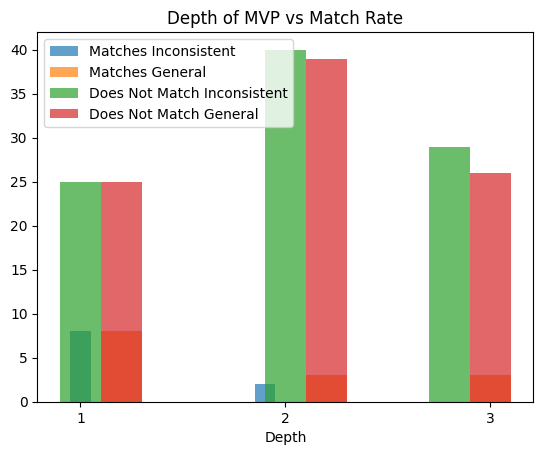

In [13]:
# histogram of depth of mwps when distractor matches inconsistent one vs general one
incon_match_depths = []
incon_no_match_depths = []
general_match_depths = []
general_no_match_depths = []

for mwp_id in data:
    if not mwp_id in incon_match_by_mwp_by_num_inst: continue # likely not solvable
    if not mwp_id in general_match_by_mwp_by_num_inst: continue

    mwp_data = data[mwp_id]
    depth = mwp_data["metadata"]["depth"]
    
    for num_inst in mwp_data["instantiations"]:
        if not solved_by_mwp_by_num_inst[mwp_id][num_inst]: continue
        if not num_inst in incon_match_by_mwp_by_num_inst[mwp_id]: continue
        if not num_inst in general_match_by_mwp_by_num_inst[mwp_id]: continue
        
        num_inst_data = mwp_data["instantiations"][num_inst]

        if incon_match_by_mwp_by_num_inst[mwp_id][num_inst]:
            incon_match_depths.append(depth)
        else:
            incon_no_match_depths.append(depth)

        if general_match_by_mwp_by_num_inst[mwp_id][num_inst]:
            general_match_depths.append(depth)
        else:
            general_no_match_depths.append(depth)

plt.figure()
plt.title("Depth of MVP vs Match Rate")
plt.xticks(range(0,5))
plt.xlabel("Depth")
plt.hist(incon_match_depths, label="Matches Inconsistent", alpha=0.7, align="left")
plt.hist(general_match_depths, label="Matches General", alpha=0.7, align="right")
plt.hist(incon_no_match_depths, label="Does Not Match Inconsistent", alpha=0.7, align="left")
plt.hist(general_no_match_depths, label="Does Not Match General", alpha=0.7, align="right")
plt.legend()

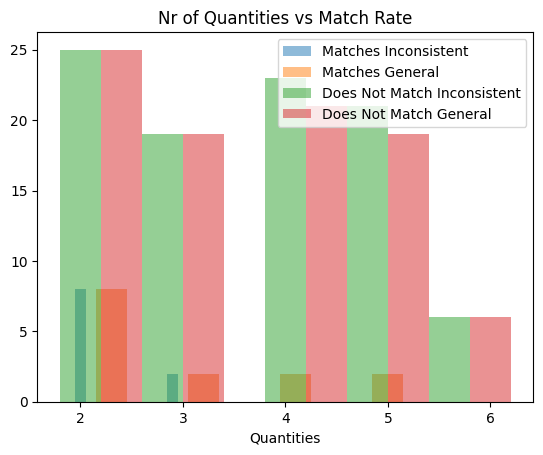

In [14]:
# plot the number of quantities vs the chance of selecting the right distractor
incon_match_numquant = []
incon_no_match_numquant = []
general_match_numquant = []
general_no_match_numquant = []

for mwp_id in data:
    if not mwp_id in incon_match_by_mwp_by_num_inst: continue
    if not mwp_id in general_match_by_mwp_by_num_inst: continue

    mwp_data = data[mwp_id]
    
    for num_inst in mwp_data["instantiations"]:
        if not solved_by_mwp_by_num_inst[mwp_id][num_inst]: continue
        if not num_inst in incon_match_by_mwp_by_num_inst[mwp_id]: continue
        if not num_inst in general_match_by_mwp_by_num_inst[mwp_id]: continue

        num_inst_data = mwp_data["instantiations"][num_inst]
        num_quant = len(num_inst_data["instantiation"])
        if incon_match_by_mwp_by_num_inst[mwp_id][num_inst]:
            incon_match_numquant.append(num_quant)
        else:
            incon_no_match_numquant.append(num_quant)

        if general_match_by_mwp_by_num_inst[mwp_id][num_inst]:
            general_match_numquant.append(num_quant)
        else:
            general_no_match_numquant.append(num_quant)

plt.figure()
plt.title("Nr of Quantities vs Match Rate")
plt.xticks(range(0,32))
plt.xlabel("Quantities")
plt.hist(incon_match_numquant, label="Matches Inconsistent", alpha=0.5, align="left")
plt.hist(general_match_numquant, label="Matches General", alpha=0.5, align="right")
plt.hist(incon_no_match_numquant, label="Does Not Match Inconsistent", alpha=0.5, align="left")
plt.hist(general_no_match_numquant, label="Does Not Match General", alpha=0.5, align="right")
plt.legend()

In [15]:
print(f"# Suggested distractor match the inconsistent one (in MWPs with >2 quantities): {len([q for q in incon_match_numquant if q > 2])} / {len([q for q in incon_no_match_numquant if q > 2])}")

# Suggested distractor match the inconsistent one (in MWPs with >2 quantities): 2 / 69


In [16]:
# do the distractors match less often if the problem contains hypotheticals, i.e. "if we were to"
match_hypo = 0
total_hypo = 0
match_normal = 0
total_normal = 0
for mwp_id in data:
    mwp_data = data[mwp_id]
    for num_inst in mwp_data["instantiations"]:
        num_inst_data = mwp_data["instantiations"][num_inst]
        is_hypo = "If we" in num_inst_data["problem"]
        match = incon_match_by_mwp_by_num_inst[mwp_id][num_inst]
        if is_hypo:
            match_hypo += match
            total_hypo += 1
        else:
            match_normal += match
            total_normal += 1
print(f"Matches for problems with hypothetical formulations: {match_hypo}/{total_hypo} = {round(100*match_hypo/total_hypo)}%")
print(f"Matches for problems without hypothetical formulations: {match_normal}/{total_normal} = {round(100*match_normal/total_normal)}%")

KeyError: '0'

In [17]:
# error-reasoning for non-matches
for mwp_id in data:
    if not mwp_id in incon_match_by_mwp_by_num_inst: continue
    
    mwp_data = data[mwp_id]
    for num_inst in mwp_data["instantiations"]:
        if not num_inst in incon_match_by_mwp_by_num_inst[mwp_id]: continue

        num_inst_data = mwp_data["instantiations"][num_inst]
        if solved_by_mwp_by_num_inst[mwp_id][num_inst]:
            if not incon_match_by_mwp_by_num_inst[mwp_id][num_inst]:
                print(f"Problem: {num_inst_data['problem']}")
                print(num_inst_data["llm_distractor"]["response"])
                print(f"Op-Pert Errors: {sorted(num_inst_data['all_op_perturbation_answers'])}")
                print()
                print("-"*100)
                print()

Problem: Evelyn has 67 black watches. Then Evelyn donates 6 black watches to Jackson. Then Ella buys 22 of Evelyn's black watches. How many black watches does Evelyn have?
["**Incorrect Answer: 59**\n\n**Step-by-Step Reasoning Trace:**\n\n1. Evelyn starts with 67 black watches.\n2. When Evelyn donates 6 black watches to Jackson, she still has 67 - 6 = 61 black watches. (This is correct so far.)\n3. However, the student mistakenly thinks that Ella buying 22 of Evelyn's black watches means that Evelyn now has 61 - 22 = 39 black watches. (This is incorrect because the student forgot that Ella is buying the watches from Evelyn, not donating them to her.)\n4. The student mistakenly thinks that the number of watches Evelyn has decreased by 22, so they subtract 22 from the original number of watches Evelyn had after donating 6 watches (61), resulting in 61 - 22 = 39. (This is incorrect because the student forgot that Ella's purchase is a transfer of ownership, not a reduction in Evelyn's tota

In [18]:
# error-reasoning for matches
for mwp_id in data:
    if not mwp_id in incon_match_by_mwp_by_num_inst: continue
    
    mwp_data = data[mwp_id]
    for num_inst in mwp_data["instantiations"]:
        if not num_inst in incon_match_by_mwp_by_num_inst[mwp_id]: continue
        
        num_inst_data = mwp_data["instantiations"][num_inst]
        if solved_by_mwp_by_num_inst[mwp_id][num_inst]:
            if incon_match_by_mwp_by_num_inst[mwp_id][num_inst]:
                print(f"Problem: {num_inst_data['problem']}")
                print(num_inst_data["llm_distractor"]["response"])
                print()
                print("-"*100)
                print()

Problem: Isabella has 63 vases. Then Ava gets 9 of Isabella's vases. How many vases does Isabella have?
["**Incorrect Answer: 72**\n\n**Step-by-Step Reasoning Trace:**\n\n1. Isabella starts with 63 vases.\n2. Ava gets 9 vases from Isabella, but this means Ava now has 9 vases, not that Isabella loses 9 vases. (Misconception: assuming the transfer of vases affects the number of vases Isabella has directly)\n3. Since Ava has 9 vases, and Isabella gave them to Ava, Isabella must have 9 more vases than she originally had. (Misconception: assuming the transfer of vases increases Isabella's total count)\n4. To find the new total, add 9 to the original number of vases Isabella had: 63 + 9 = 72.\n\nThis distractor is based on a common student misconception that the transfer of objects affects the original owner's count directly, rather than understanding that the transfer reduces the original owner's count.", '72']

-------------------------------------------------------------------------------

In [19]:
# error-reasoning for matches with quantities > 2
for mwp_id in data:
    if not mwp_id in incon_match_by_mwp_by_num_inst: continue

    mwp_data = data[mwp_id]

    for num_inst in mwp_data["instantiations"]:
        if not num_inst in incon_match_by_mwp_by_num_inst[mwp_id]: continue
        
        num_inst_data = mwp_data["instantiations"][num_inst]
        num_quant = len(num_inst_data["instantiation"])
        if num_quant <= 2: continue
        
        if solved_by_mwp_by_num_inst[mwp_id][num_inst]:
            if incon_match_by_mwp_by_num_inst[mwp_id][num_inst]:
                print(f"Problem: {num_inst_data['problem']}")
                print(num_inst_data["llm_distractor"]["response"])
                print()
                print("-"*100)
                print()

Problem: Jonathan has 58 white plates. If we were to take away 14 white plates from Jonathan, then Jonathan would have as many white plates as Nathan. Nathan has 7 more white plates than Ryan. How many white plates does Ryan have?
["Incorrect Answer: 49\n\nStep-by-Step Reasoning Trace:\n\n1. The student might start by understanding that Jonathan has 58 white plates and 14 are taken away, leaving him with 58 - 14 = 44 white plates.\n2. The student might then think that since Nathan has 7 more white plates than Ryan, and Jonathan now has the same number of plates as Nathan, they might assume that the difference between Nathan's and Ryan's plates is 7, but they might not consider that this difference is in addition to the number of plates Nathan has.\n3. The student might then think that since Jonathan has 44 plates and Nathan has 7 more, Nathan has 44 + 7 = 51 plates.\n4. The student might then think that since Nathan has 51 plates and Ryan has 7 fewer plates than Nathan, Ryan must have 

In [20]:
# error-reasoning for matches with quantities > 2 that is non-linear
for mwp_id in data:
    if not mwp_id in incon_match_by_mwp_by_num_inst: continue

    mwp_data = data[mwp_id]
    
    # check if non-linear
    mwp_rules = set(mwp_data["metadata"]["orig_rules_by_conclusion"].values())
    nonlinear_rules = set(["ContCompCompeqCont", "ContPartWhole"])
    if len(mwp_rules.intersection(nonlinear_rules)) == 0: continue

    for num_inst in mwp_data["instantiations"]:
        if not num_inst in incon_match_by_mwp_by_num_inst[mwp_id]: continue

        num_inst_data = mwp_data["instantiations"][num_inst]

        # check if >2 quantities
        num_quant = len(num_inst_data["instantiation"])
        if num_quant <= 2: continue
        
        if solved_by_mwp_by_num_inst[mwp_id][num_inst]:
            if incon_match_by_mwp_by_num_inst[mwp_id][num_inst]:
                print(f"Problem: {num_inst_data['problem']}")
                print(num_inst_data["llm_distractor"]["response"])
                print()
                print("-"*100)
                print()

In [21]:
# error-reasoning for matches with only 2 quantities and that do not match (what other options are there even?)
nr_no_match = 0
nr_total = 0
for mwp_id in data:
    if not mwp_id in incon_match_by_mwp_by_num_inst: continue
    mwp_data = data[mwp_id]

    for num_inst in mwp_data["instantiations"]:
        if not num_inst in incon_match_by_mwp_by_num_inst[mwp_id]: continue
        
        num_inst_data = mwp_data["instantiations"][num_inst]

        # check if <=2 quantities
        num_quant = len(num_inst_data["instantiation"])
        if num_quant > 2: continue
        
        if solved_by_mwp_by_num_inst[mwp_id][num_inst]:
            if not incon_match_by_mwp_by_num_inst[mwp_id][num_inst]:
                print(f"Problem: {num_inst_data['problem']}")
                print(f"Correct Answer: {num_inst_data['correct_answer']}")
                print(f"Inconsistent Answers: {num_inst_data['misconception_answers']}")
                print(num_inst_data["llm_distractor"]["response"])
                print()
                print("-"*100)
                print()
                nr_no_match += 1
            nr_total += 1
print(f"# Non matches with <=2 quantities that are solved incorrectly: {nr_no_match}/{nr_total}")

Problem: Isabella has 55 vases. Then Ava gets 22 of Isabella's vases. How many vases does Isabella have?
Correct Answer: {'answer': 33}
Inconsistent Answers: [{'answer': 77, 'expression': '(quantity_1) + (quantity_2)', 'misconceptions': {'1': 'ContTransferContMisconceptionIncons'}, 'plausible': True}]
["**Incorrect Answer: 75**\n\n**Step-by-Step Reasoning Trace:**\n\n1. Isabella starts with 55 vases.\n2. Ava gets 22 vases from Isabella, but this means Ava now has 22 vases, not that Isabella loses 22 vases. (Misconception: assuming the transfer of vases affects Isabella's count directly)\n3. Since Ava has 22 vases, and Isabella gave them to Ava, Isabella must have 22 more vases than she originally had. (Misconception: misunderstanding the concept of subtraction)\n4. To find out how many vases Isabella has now, we need to add 22 to the original number of vases she had. (Misconception: incorrectly applying addition instead of subtraction)\n5. So, 55 (original vases) + 22 (additional vases

In [22]:
# error-reasoning for mwps with compeq but no partwhole that do not match the inconsistent ones
nr_no_match = 0
nr_total = 0
for mwp_id in data:
    if not mwp_id in incon_match_by_mwp_by_num_inst: continue
    mwp_data = data[mwp_id]
    
    mwp_rules = set(mwp_data["metadata"]["orig_rules_by_conclusion"].values())
    whitelist_rules = set(["ContCompCompeqCont"])
    blacklist_rules = set(["ContPartWhole"])
    if len(mwp_rules.intersection(nonlinear_rules)) == 0 or len(mwp_rules.intersection(blacklist_rules)) != 0: continue

    for num_inst in mwp_data["instantiations"]:
        if not num_inst in incon_match_by_mwp_by_num_inst[mwp_id]: continue
        
        num_inst_data = mwp_data["instantiations"][num_inst]
        
        if solved_by_mwp_by_num_inst[mwp_id][num_inst]:
            if not incon_match_by_mwp_by_num_inst[mwp_id][num_inst]:
                print(f"Problem: {num_inst_data['problem']}")
                print(num_inst_data["llm_distractor"]["response"])
                print()
                print("-"*100)
                print()
                nr_no_match += 1
            nr_total += 1
print(f"# Non matches with CompEq but no Partwhole: {nr_no_match}/{nr_total}")

Problem: Lily has 73 yellow bottles of soap. If we were to take away 6 yellow bottles of soap from Lily, then Lily would have as many yellow bottles of soap as Hannah. Joseph has 14 yellow bottles of soap. Avery has 4 yellow bottles of soap. The number of yellow bottles of soap that Hannah has more than Layla is equal to the difference in the number of yellow bottles of soap that Joseph has compared to Avery. Then Matthew gives Layla 22 yellow bottles of soap. How many yellow bottles of soap does Layla have?
['**Incorrect Answer:**\n\nLily has 73 yellow bottles of soap. If we were to take away 6 yellow bottles of soap from Lily, then Lily would have as many yellow bottles of soap as Hannah. Joseph has 14 yellow bottles of soap. Avery has 4 yellow bottles of soap. The number of yellow bottles of soap that Hannah has more than Layla is equal to the difference in the number of yellow bottles of soap that Joseph has compared to Avery. Then Matthew gives Layla 22 yellow bottles of soap.\n\n

In [23]:
# error-reasoning for mwps with partwhole but no compeq that do not match the inconsistent ones
nr_no_match = 0
nr_total = 0
for mwp_id in data:
    if not mwp_id in incon_match_by_mwp_by_num_inst: continue
    mwp_data = data[mwp_id]
    
    mwp_rules = set(mwp_data["metadata"]["orig_rules_by_conclusion"].values())
    whitelist_rules = set(["ContPartWhole"])
    blacklist_rules = set(["ContCompCompeqCont"])
    if len(mwp_rules.intersection(nonlinear_rules)) == 0 or len(mwp_rules.intersection(blacklist_rules)) != 0: continue

    for num_inst in mwp_data["instantiations"]:
        if not num_inst in incon_match_by_mwp_by_num_inst[mwp_id]: continue
        num_inst_data = mwp_data["instantiations"][num_inst]
        
        if solved_by_mwp_by_num_inst[mwp_id][num_inst]:
            if not incon_match_by_mwp_by_num_inst[mwp_id][num_inst]:
                print(f"Problem: {num_inst_data['problem']}")
                print(num_inst_data["llm_distractor"]["response"])
                print()
                print("-"*100)
                print()
                nr_no_match += 1
            nr_total += 1
print(f"# Non matches with CompEq but no Partwhole: {nr_no_match}/{nr_total}")

Problem: Lily has 60 packages. Then Charlotte gets 22 of Lily's packages. Samuel has 61 bags. Then Samuel gifts 6 bags to Harper. Matthew has 74 backpacks. If we were to take away 3 backpacks from Matthew, then Matthew would have as many backpacks as Mason. How many containers do Lily, Samuel and Mason have combined?
['**Incorrect Answer: 120**\n\n**Step-by-Step Reasoning Trace:**\n\n1. The student might start by focusing on the initial information about Lily and Samuel, and incorrectly assume that the question is asking for the total number of packages or bags they have. They might think, "Lily has 60 packages and Samuel has 61 bags, so if we add them together, we get 60 + 61 = 121."\n2. The student might then ignore the information about Charlotte getting 22 packages from Lily, thinking it\'s not relevant to the question. They might think, "We don\'t need to worry about Charlotte, she\'s not part of the question."\n3. The student might also ignore the information about Samuel gifting

In [24]:
# gives the correct answer as the distractor
for mwp_id in data:
    if not mwp_id in incon_eq_correct_by_mwp_by_num_inst: continue
    mwp_data = data[mwp_id]

    for num_inst in mwp_data["instantiations"]:
        if not num_inst in incon_eq_correct_by_mwp_by_num_inst[mwp_id]: continue
        num_inst_data = mwp_data["instantiations"][num_inst]
        print(f"Problem: {num_inst_data['problem']}")
        print(num_inst_data["llm_distractor"]["response"])
        print()
        print("-"*100)
        print()

Problem: Evelyn has 67 black watches. Then Evelyn donates 6 black watches to Jackson. Then Ella buys 22 of Evelyn's black watches. How many black watches does Evelyn have?
["**Incorrect Answer: 59**\n\n**Step-by-Step Reasoning Trace:**\n\n1. Evelyn starts with 67 black watches.\n2. When Evelyn donates 6 black watches to Jackson, she still has 67 - 6 = 61 black watches. (This is correct so far.)\n3. However, the student mistakenly thinks that Ella buying 22 of Evelyn's black watches means that Evelyn now has 61 - 22 = 39 black watches. (This is incorrect because the student forgot that Ella is buying the watches from Evelyn, not donating them to her.)\n4. The student mistakenly thinks that the number of watches Evelyn has decreased by 22, so they subtract 22 from the original number of watches Evelyn had after donating 6 watches (61), resulting in 61 - 22 = 39. (This is incorrect because the student forgot that Ella's purchase is a transfer of ownership, not a reduction in Evelyn's tota